In [1]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('train.csv',usecols=['Age','Fare','Survived'])
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [4]:
df.isnull().mean() * 100

Survived     0.00000
Age         19.86532
Fare         0.00000
dtype: float64

In [5]:
X = df.drop(columns=['Survived'])
y = df['Survived']

In [6]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [7]:
X_train

,Age,Fare
30,40.0,27.7208
10,4.0,16.7000
873,47.0,9.0000
182,9.0,31.3875
876,20.0,9.8458
...,...,...
534,30.0,8.6625
584,NaN,8.7125
493,71.0,49.5042
527,NaN,221.7792


In [8]:
X_train['Age_imputed'] = X_train['Age']
X_test['Age_imputed'] = X_test['Age']

In [9]:
X_train.sample(5)

,Age,Fare,Age_imputed
642,2.0,27.9000,2.0
285,33.0,8.6625,33.0
837,NaN,8.0500,NaN
221,27.0,13.0000,27.0
843,34.5,6.4375,34.5


In [14]:
train_missing = X_train['Age_imputed'].isna()
test_missing = X_test['Age_imputed'].isna()

X_train.loc[train_missing, 'Age_imputed'] = (
    X_train['Age'].dropna()
    .sample(train_missing.sum(), random_state=42)
    .to_numpy()
)

X_test.loc[test_missing, 'Age_imputed'] = (
    X_train['Age'].dropna()
    .sample(test_missing.sum(), random_state=42)
    .to_numpy()
)

In [15]:
X_train['Age'].dropna().sample(X_train['Age'].isnull().sum()).values

array([38.  , 20.  , 18.  , 30.  , 33.  , 28.  , 20.  , 54.  , 32.  ,
       42.  ,  3.  , 19.  , 25.  , 19.  , 59.  , 25.  , 40.  , 22.  ,
       18.  , 28.  , 32.  , 25.  , 36.  , 44.  , 23.  , 30.  , 22.  ,
       13.  , 31.  ,  4.  , 65.  , 26.  , 65.  , 14.  ,  2.  , 45.  ,
       30.  , 21.  , 35.  , 23.  , 29.  , 49.  , 57.  , 19.  , 25.  ,
       49.  , 11.  , 32.  , 39.  , 27.  , 29.  , 34.  , 21.  , 28.  ,
        9.  ,  7.  , 44.  , 28.  , 26.  , 27.  , 22.  , 21.  , 47.  ,
       16.  ,  0.67, 18.  , 32.  , 18.  , 52.  , 21.  ,  2.  , 18.  ,
       18.  , 51.  ,  5.  , 29.  , 19.  , 24.  , 26.  , 32.  , 21.  ,
       19.  , 18.  , 27.  , 19.  , 61.  ,  9.  , 30.  , 29.  , 40.  ,
       35.  , 36.  , 36.  , 27.  , 48.  ,  6.  , 36.  , 27.  , 22.  ,
       22.  , 24.  , 56.  , 22.  , 16.  ,  2.  , 28.  , 35.  , 34.  ,
       26.  , 23.  , 54.  , 45.  , 60.  , 25.  , 34.  , 62.  ,  2.  ,
       23.5 , 31.  , 27.  , 30.  , 42.  , 42.  , 39.  , 22.  , 32.  ,
       17.  , 39.  ,

In [17]:
X_train['Age'].isnull().sum()

np.int64(148)

In [18]:
X_train

,Age,Fare,Age_imputed
30,40.0,27.7208,40.0
10,4.0,16.7000,4.0
873,47.0,9.0000,47.0
182,9.0,31.3875,9.0
876,20.0,9.8458,20.0
...,...,...,...
534,30.0,8.6625,30.0
584,NaN,8.7125,20.0
493,71.0,49.5042,71.0
527,NaN,221.7792,16.0


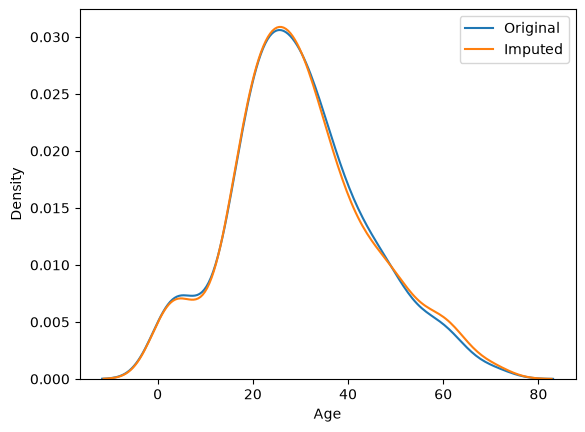

In [20]:
sns.kdeplot(X_train['Age'], label='Original')
sns.kdeplot(X_train['Age_imputed'], label='Imputed')

plt.legend()
plt.show()

In [21]:
print('Original variable variance: ', X_train['Age'].var())
print('Variance after random imputation: ', X_train['Age_imputed'].var())

Original variable variance:  204.34951339046142
Variance after random imputation:  213.26062804228104


In [22]:
X_train[['Fare', 'Age', 'Age_imputed']].cov()

,Fare,Age,Age_imputed
Fare,2368.246832,71.512440,41.815166
Age,71.512440,204.349513,204.349513
Age_imputed,41.815166,204.349513,213.260628


<Axes: >

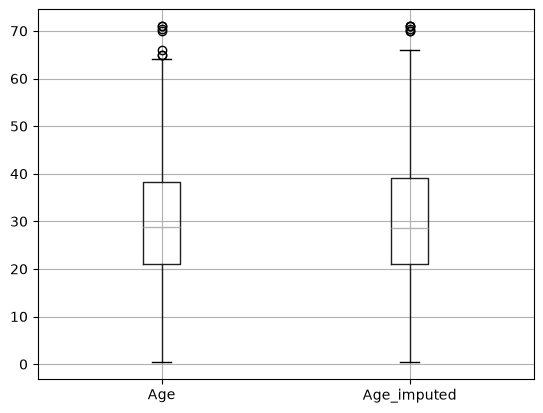

In [23]:
X_train[['Age', 'Age_imputed']].boxplot()

In [25]:
for index, observation in X_train.iterrows():
    if pd.isna(observation['Age_imputed']):
        sampled_value = X_train['Age'].dropna().sample(
            1,
            random_state=int(observation['Fare'])
        )
        X_train.loc[index, 'Age_imputed'] = sampled_value.iloc[0]

In [26]:
data = pd.read_csv('house-train.csv',usecols=['GarageQual','FireplaceQu', 'SalePrice'])

In [27]:
data.head()

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000


In [28]:
data.isnull().mean() * 100

FireplaceQu    47.260274
GarageQual      5.547945
SalePrice       0.000000
dtype: float64

In [29]:
X = data
y = data['SalePrice']

In [30]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [31]:
X_train['GarageQual_imputed'] = X_train['GarageQual']
X_test['GarageQual_imputed'] = X_test['GarageQual']

X_train['FireplaceQu_imputed'] = X_train['FireplaceQu']
X_test['FireplaceQu_imputed'] = X_test['FireplaceQu']


In [32]:
X_train.sample(5)

,FireplaceQu,GarageQual,SalePrice,GarageQual_imputed,FireplaceQu_imputed
147,Gd,TA,222500,TA,Gd
880,NaN,TA,157000,TA,NaN
368,Gd,TA,132000,TA,Gd
258,TA,TA,231500,TA,TA
201,Fa,TA,171500,TA,Fa


In [34]:
# GarageQual
garage_train_missing = X_train['GarageQual_imputed'].isna()
garage_test_missing = X_test['GarageQual_imputed'].isna()

X_train.loc[garage_train_missing, 'GarageQual_imputed'] = (
    X_train['GarageQual']
    .dropna()
    .sample(garage_train_missing.sum(), random_state=42)
    .to_numpy()
)

X_test.loc[garage_test_missing, 'GarageQual_imputed'] = (
    X_train['GarageQual']
    .dropna()
    .sample(garage_test_missing.sum(), random_state=42)
    .to_numpy()
)


# FireplaceQu
fireplace_train_missing = X_train['FireplaceQu_imputed'].isna()
fireplace_test_missing = X_test['FireplaceQu_imputed'].isna()

X_train.loc[fireplace_train_missing, 'FireplaceQu_imputed'] = (
    X_train['FireplaceQu']
    .dropna()
    .sample(fireplace_train_missing.sum(), random_state=42)
    .to_numpy()
)

X_test.loc[fireplace_test_missing, 'FireplaceQu_imputed'] = (
    X_train['FireplaceQu']
    .dropna()
    .sample(fireplace_test_missing.sum(), random_state=42)
    .to_numpy()
)

In [35]:
temp = pd.concat(
        [
            X_train['GarageQual'].value_counts() / len(X_train['GarageQual'].dropna()),
            X_train['GarageQual_imputed'].value_counts() / len(X_train)
        ],
        axis=1)

temp.columns = ['original', 'imputed']

In [36]:
temp

,original,imputed
TA,0.951043,0.952055
Fa,0.037171,0.036815
Gd,0.009973,0.009418
Po,0.000907,0.000856
Ex,0.000907,0.000856


In [37]:
temp = pd.concat(
        [
            X_train['FireplaceQu'].value_counts() / len(X_train['FireplaceQu'].dropna()),
            X_train['FireplaceQu_imputed'].value_counts() / len(df)
        ],
        axis=1)

temp.columns = ['original', 'imputed']

temp

,original,imputed
Gd,0.494272,0.655443
TA,0.412439,0.533109
Fa,0.040917,0.052750
Po,0.027823,0.037037
Ex,0.024550,0.032548


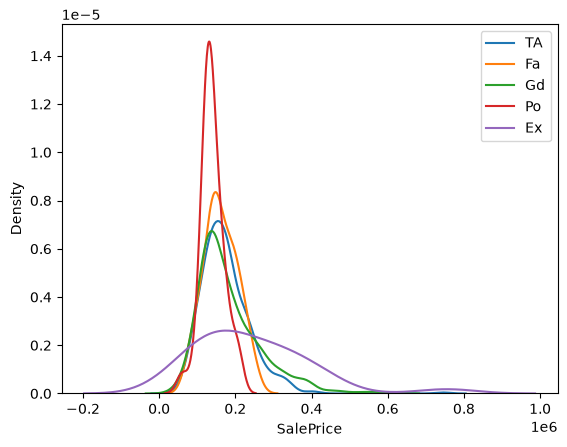

In [41]:
for category in X_train['FireplaceQu_imputed'].dropna().unique():
    sns.kdeplot(
        X_train[X_train['FireplaceQu_imputed'] == category]['SalePrice'],
        label=category
    )

plt.legend()
plt.show()